# Tagger Baseado em RNN e LSTM

In [ ]:
# 1. Clona o projeto para o ambiente temporário do Colab
!git clone https://github.com/lucasaamorim/NLP

Cloning into 'NLP'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 183 (delta 73), reused 133 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 8.02 MiB | 22.81 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [ ]:
# 2. Entra na pasta do projeto
%cd NLP

/content/NLP


In [ ]:
# 3. Instala o arquivo de dependências (caso o notebook use algo além do TensorFlow padrão)
!uv pip install keras scikit-learn nltk regex

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 248ms


In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

!unzip glove.6B.zip

In [ ]:
import numpy as np
import keras
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.utils.data_loader import load_tagging_data, load_pretrained_embeddings
from src.utils.preprocessing import tokenize_sentences, vectorize_tags, build_embedding_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/pos_tagging_data/data

/content/drive/MyDrive/pos_tagging_data/data


In [ ]:
# ln -s /caminho/real/no/drive /content/nome_que_o_codigo_espera
!ln -s "/content/drive/MyDrive/pos_tagging_data/data" "/content/NLP/data"

###Carregando os dados de POS Tagging

In [ ]:
data = load_tagging_data()
print("Dados do POS Tagging carregados")

Dados do POS Tagging carregados


###Separando os splits originais

In [ ]:
train_sentences = data["train"]["sentences"]
train_tags = data["train"]["tags"]

val_sentences = data["val"]["sentences"]
val_tags = data["val"]["tags"]

test_sentences = data["test"]["sentences"]
test_tags = data["test"]["tags"]

print(f"Sentenças de Treino: {len(train_sentences)} | Validação: {len(val_sentences)} | Teste: {len(test_sentences)}")

Sentenças de Treino: 38219 | Validação: 5527 | Teste: 5462


###Processando o Vocabulário de Palavras

In [ ]:
vocab_size = 8000  # Limite máximo de palavras únicas
vectorizer, max_len = tokenize_sentences(train_sentences, vocab_size)

X_train = vectorizer([" ".join(s) for s in train_sentences]).numpy()
X_val = vectorizer([" ".join(s) for s in val_sentences]).numpy()
X_test = vectorizer([" ".join(s) for s in test_sentences]).numpy()

###Processando o Vocabulário de Tags

In [ ]:
tag_lookup, Y_train = vectorize_tags(train_tags, max_len)

num_tags = tag_lookup.vocabulary_size()

_, Y_val = vectorize_tags(val_tags, max_len, existing_lookup=tag_lookup)
_, Y_test = vectorize_tags(test_tags, max_len, existing_lookup=tag_lookup)

print(f"Formato final de X_train: {X_train.shape}")
print(f"Formato final de Y_train: {Y_train.shape}")
print(f"Formato final de X_test: {X_test.shape}")
print(f"Formato final de Y_test: {Y_test.shape}")
print(f"Número total de tags (classes): {num_tags}")

Formato final de X_train: (38219, 249)
Formato final de Y_train: (38219, 249)
Formato final de X_test: (5462, 249)
Formato final de Y_test: (5462, 249)
Número total de tags (classes): 47


In [ ]:
# Hiperparâmetros
embedding_dim = 50
rnn_units = 128
BATCH_SIZE = 32
EPOCHS = 5
glove_path = f"/content/NLP/data/glove.6B.{embedding_dim}d.txt"

glove_index = load_pretrained_embeddings(glove_path)
embedding_matrix = build_embedding_matrix(vectorizer, glove_index, embedding_dim)

inputs = keras.Input(shape=(max_len,), dtype="int32")

rnn = layers.Embedding(
    input_dim=vectorizer.vocabulary_size(),
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    output_dim=embedding_dim,
    trainable=True,
    mask_zero=True
)(inputs)

###Construindo o modelo RNN unidirecional

In [ ]:
rnn_unidirecional = layers.SimpleRNN(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_unidirecional)

rnn_unidirecional_model = keras.Model(inputs, outputs)

rnn_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_unidirecional_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 249, 128)  │     32,896 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 249, 47)   │      6,063 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,062,959 (4.05 MB)

 Trainable params: 1,062,959 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM unidirecional


In [ ]:
lstm_unidirecional = layers.LSTM(rnn_units, return_sequences=True)(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(lstm_unidirecional)

lstm_unidirecional_model = keras.Model(inputs, outputs)

lstm_unidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_unidirecional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 249, 128)  │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 249, 47)   │      6,063 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,161,647 (4.43 MB)

 Trainable params: 1,161,647 (4.43 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo RNN bidirecional

In [ ]:
rnn_bidirecional = layers.Bidirectional(layers.SimpleRNN(rnn_units, return_sequences=True))(rnn)

outputs = layers.Dense(num_tags, activation="softmax")(rnn_bidirecional)

rnn_bidirecional_model = keras.Model(inputs, outputs)

rnn_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_bidirecional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 249, 256)  │     65,792 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 249, 47)   │     12,079 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,101,871 (4.20 MB)

 Trainable params: 1,101,871 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

###Construindo o modelo LSTM Bidirecional

In [ ]:
# RNN Bidirecional para capturar contexto tanto da esquerda-para-direita quanto da direita-para-esquerda
lstm_bidirecional = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True))(rnn)

# Camada densa distribuída no tempo (computa uma distribuição de probabilidade por palavra)
outputs = layers.Dense(num_tags, activation="softmax")(lstm_bidirecional)

lstm_bidirecional_model = keras.Model(inputs, outputs)

# Usamos SparseCategoricalCrossentropy porque nosso Y contém IDs inteiros (não one-hot vectors)
lstm_bidirecional_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_bidirecional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 249)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 249, 128)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 249)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 249, 256)  │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 249, 47)   │     12,079 │ bidirectional_1[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,299,247 (4.96 MB)

 Trainable params: 1,299,247 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

### Treinamento da RNN Unidirecional

In [ ]:
history = rnn_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 235s 195ms/step - accuracy: 0.8638 - loss: 0.4940 - val_accuracy: 0.8761 - val_loss: 0.8633
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 230s 193ms/step - accuracy: 0.9295 - loss: 0.2024 - val_accuracy: 0.8792 - val_loss: 0.9086
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 235s 197ms/step - accuracy: 0.9356 - loss: 0.1822 - val_accuracy: 0.8800 - val_loss: 0.9345
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 229s 192ms/step - accuracy: 0.9408 - loss: 0.1680 - val_accuracy: 0.8802 - val_loss: 0.9904
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 231s 194ms/step - accuracy: 0.9449 - loss: 0.1560 - val_accuracy: 0.8795 - val_loss: 1.0179


### Treinamento da LSTM Unidirecional

In [ ]:
history = lstm_unidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 644s 537ms/step - accuracy: 0.8893 - loss: 0.4191 - val_accuracy: 0.8795 - val_loss: 0.8959
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 680s 535ms/step - accuracy: 0.9368 - loss: 0.1799 - val_accuracy: 0.8812 - val_loss: 0.9431
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 655s 548ms/step - accuracy: 0.9423 - loss: 0.1634 - val_accuracy: 0.8833 - val_loss: 0.9815
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 671s 539ms/step - accuracy: 0.9461 - loss: 0.1517 - val_accuracy: 0.8822 - val_loss: 1.0198
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 640s 536ms/step - accuracy: 0.9500 - loss: 0.1414 - val_accuracy: 0.8825 - val_loss: 1.0630


### Treinamento da RNN Bidirecional

In [ ]:
history = rnn_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 225s 186ms/step - accuracy: 0.8856 - loss: 0.4100 - val_accuracy: 0.8949 - val_loss: 0.8202
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 268s 192ms/step - accuracy: 0.9480 - loss: 0.1551 - val_accuracy: 0.8959 - val_loss: 0.8786
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 265s 194ms/step - accuracy: 0.9542 - loss: 0.1346 - val_accuracy: 0.8979 - val_loss: 0.9201
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 262s 194ms/step - accuracy: 0.9591 - loss: 0.1191 - val_accuracy: 0.8974 - val_loss: 0.9601
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 229s 191ms/step - accuracy: 0.9638 - loss: 0.1059 - val_accuracy: 0.8963 - val_loss: 1.0008


### Treinamento da LSTM Bidirecional

In [ ]:
history = lstm_bidirecional_model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, Y_val)
)

Epoch 1/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 1258s 1s/step - accuracy: 0.9286 - loss: 0.2588 - val_accuracy: 0.8980 - val_loss: 0.8410
Epoch 2/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 1281s 1s/step - accuracy: 0.9614 - loss: 0.1131 - val_accuracy: 0.8989 - val_loss: 0.8955
Epoch 3/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 1255s 1s/step - accuracy: 0.9667 - loss: 0.0972 - val_accuracy: 0.8981 - val_loss: 0.9365
Epoch 4/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 1288s 1s/step - accuracy: 0.9707 - loss: 0.0853 - val_accuracy: 0.8989 - val_loss: 0.9749
Epoch 5/5
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 1255s 1s/step - accuracy: 0.9742 - loss: 0.0749 - val_accuracy: 0.8978 - val_loss: 1.0251


###Função de Avaliação dos modelos

In [ ]:
def model_evaluation(model, X_test, Y_test, tag_lookup, model_name):
    # 1. Predict probabilities for each class per word
    predictions_prob = model.predict(X_test)

    # 2. Get the index of the class with the highest probability
    predicted_classes = np.argmax(predictions_prob, axis=-1)

    y_true_filtered = []
    y_pred_filtered = []

    # 3. Filter data by removing ID 0 (<PAD>)
    for i in range(len(Y_test)):
        for j in range(len(Y_test[i])):
            if Y_test[i][j] != 0:  # 0 is the <PAD> ID generated by StringLookup
                y_true_filtered.append(Y_test[i][j])
                y_pred_filtered.append(predicted_classes[i][j])

    # 4. Get the actual vocabulary from your tag_lookup
    full_vocabulary = tag_lookup.get_vocabulary()

    # Find which unique IDs actually remain in y_true
    present_ids = sorted(list(set(y_true_filtered)))

    # --- CORREÇÃO DO JJ E DA ORDEM ALFABÉTICA ---
    # Criamos pares de (Nome único com ID, ID original) para mapear sem duplicar no gráfico
    tag_pairs = []
    for idx in present_ids:
        tag_name = full_vocabulary[int(idx)]
        # Adiciona o ID ao nome (Resolve o problema do JJ duplicado)
        unique_name = f"{tag_name}"
        tag_pairs.append((unique_name, idx))

    # Ordena a lista de tuplas em ordem alfabética pelo nome da tag
    tag_pairs_sorted = sorted(tag_pairs, key=lambda x: x[0])

    # Separamos de volta os nomes ordenados alfabeticamente e a ordem dos IDs correspondentes
    alphabetical_names = [pair[0] for pair in tag_pairs_sorted]
    alphabetical_ids = [pair[1] for pair in tag_pairs_sorted]

    print("\n" + "="*50)
    print("Classification Report Without Padding")
    print("="*50)
    # No relatório de texto, usamos a ordem alfabética mapeando os nomes limpos (sem o sufixo do ID para o relatório ficar bonito)
    clean_alphabetical_names = [full_vocabulary[int(idx)] for idx in alphabetical_ids]
    print(classification_report(y_true_filtered, y_pred_filtered, labels=alphabetical_ids, target_names=clean_alphabetical_names, zero_division=0))

    # 5. Confusion Matrix alinhada com a nova ordem alfabética
    cm = confusion_matrix(y_true_filtered, y_pred_filtered, labels=alphabetical_ids)

    with np.errstate(all='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)

    # Aumentamos um pouco o tamanho para acomodar os espaçamentos retos das palavras
    plt.figure(figsize=(18, 14))

    # Renderiza a matriz normalizada usando os nomes em ordem alfabética e com IDs únicos
    ax = sns.heatmap(cm_normalized, annot=False, cmap="Blues", vmin=0.0, vmax=1.0,
                xticklabels=alphabetical_names, yticklabels=alphabetical_names)

    # --- CORREÇÃO DO ESPAÇAMENTO SEM ROTACIONAR ---
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=12)
    ax.tick_params(axis='y', rotation=0, labelsize=10, pad=12)

    plt.title(f"Matriz de Confusão (Normalizada) - {model_name}", fontsize=14, pad=25)
    plt.xlabel("Predito", fontsize=12, labelpad=20) # Aumentado o recuo do título do eixo X
    plt.ylabel("Real", fontsize=12, labelpad=20)    # Aumentado o recuo do título do eixo Y

    plt.tight_layout()
    plt.show()

### Avaliação da RNN Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       0.69      1.00      0.82       733
           ,       1.00      1.00      1.00      6875
       -LRB-       1.00      1.00      1.00       186
       -RRB-       0.93      1.00      0.96       174
           .       0.07      1.00      0.13       378
           :       0.88      1.00      0.94       665
          CC       0.99      0.99      0.99      3250
          CD       0.69      0.97      0.80      4821
          DT       0.92      1.00      0.96     11183
          EX       0.91      1.00      0.95       126
          FW       0.36      0.13      0.20        30
          IN       0.94      0.96      0.95     13487
          JJ       0.75      0.77      0.76      8213
         JJR       0.87      0.54      0.67       423


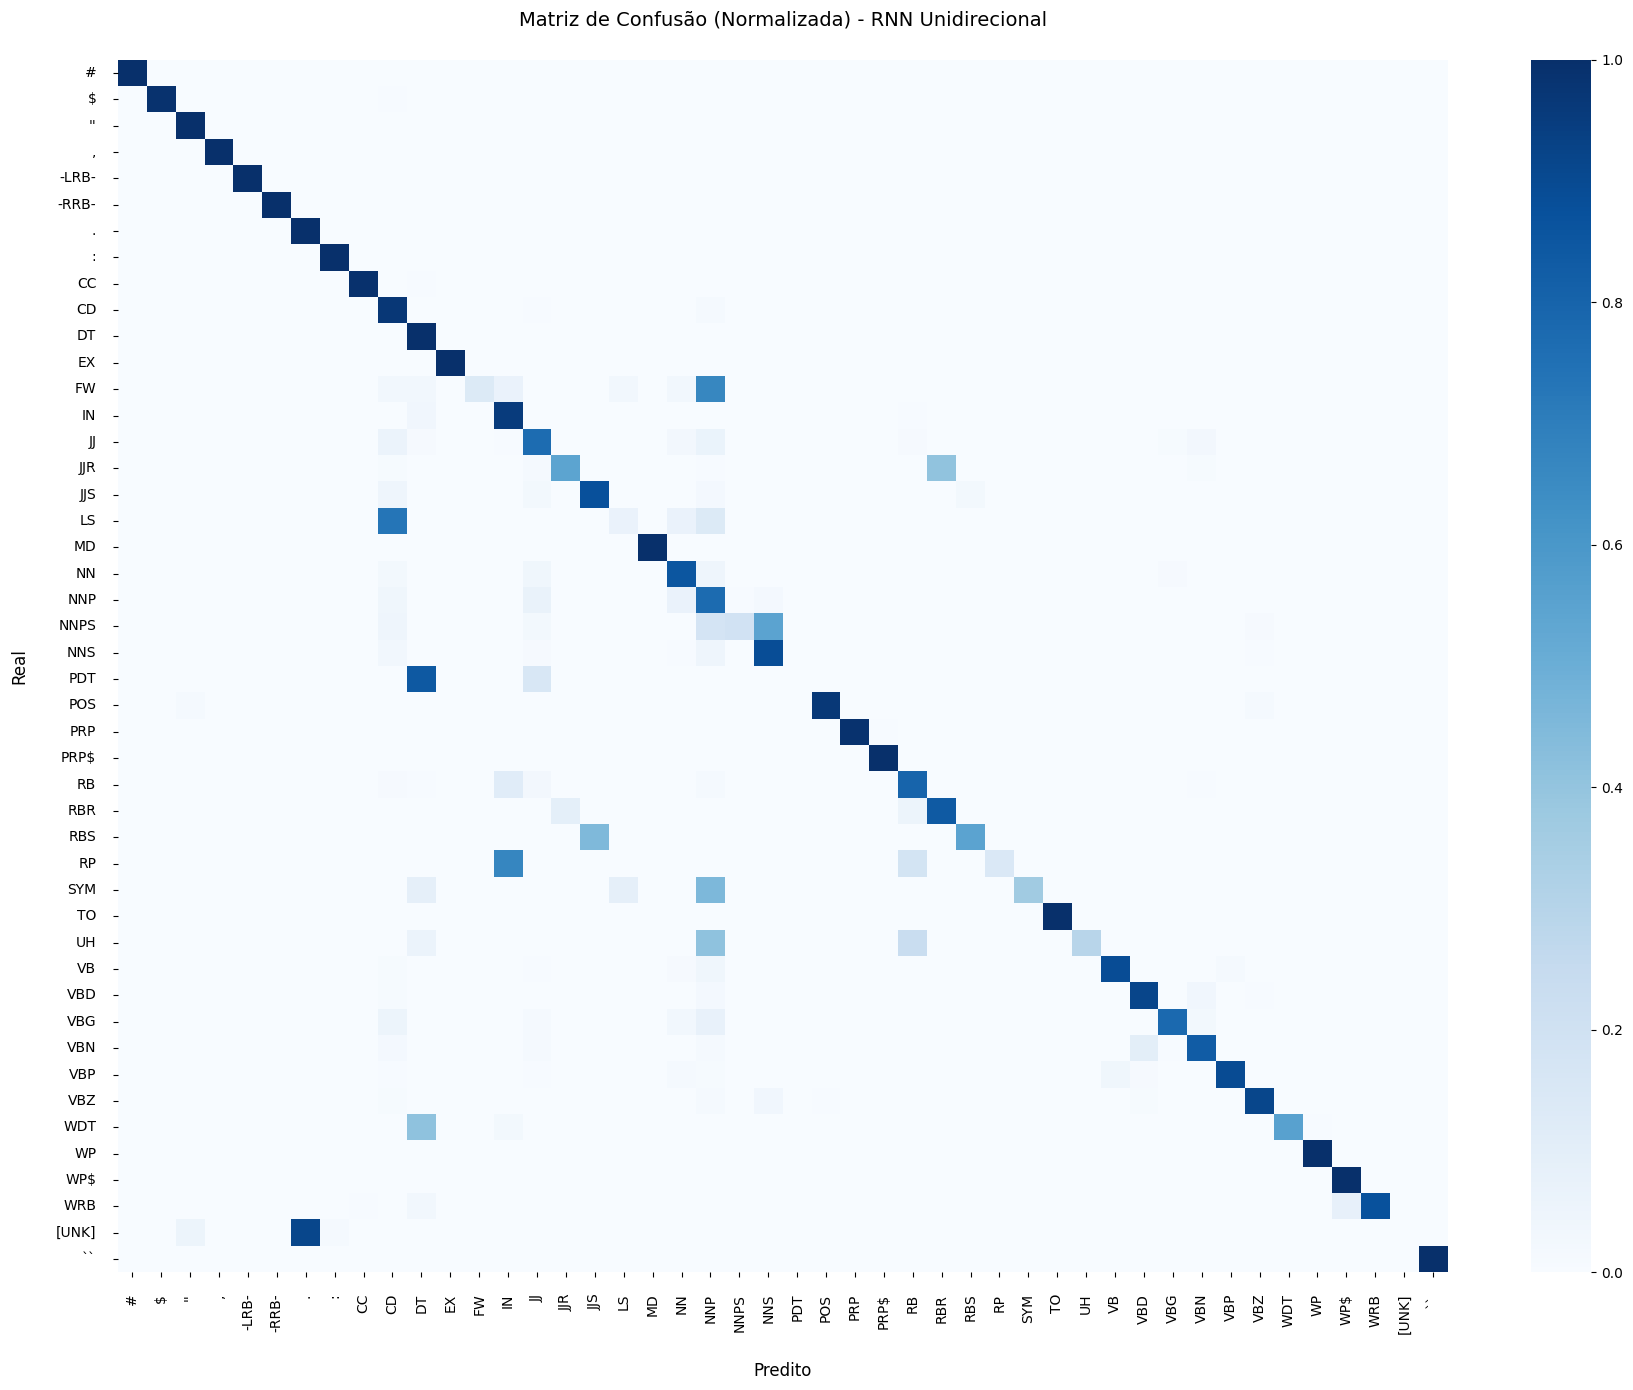

In [ ]:
model_evaluation(rnn_unidirecional_model, X_test, Y_test, tag_lookup, "RNN Unidirecional")

### Avaliação da LSTM Unidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       0.70      1.00      0.82       733
           ,       1.00      1.00      1.00      6875
       -LRB-       1.00      1.00      1.00       186
       -RRB-       0.93      1.00      0.96       174
           .       0.07      1.00      0.13       378
           :       0.88      1.00      0.94       665
          CC       0.99      0.99      0.99      3250
          CD       0.93      0.96      0.94      4821
          DT       0.98      0.99      0.99     11183
          EX       0.96      0.81      0.88       126
          FW       0.25      0.13      0.17        30
          IN       0.96      0.97      0.97     13487
          JJ       0.75      0.80      0.77      8213
         JJR       0.86      0.72      0.78       42

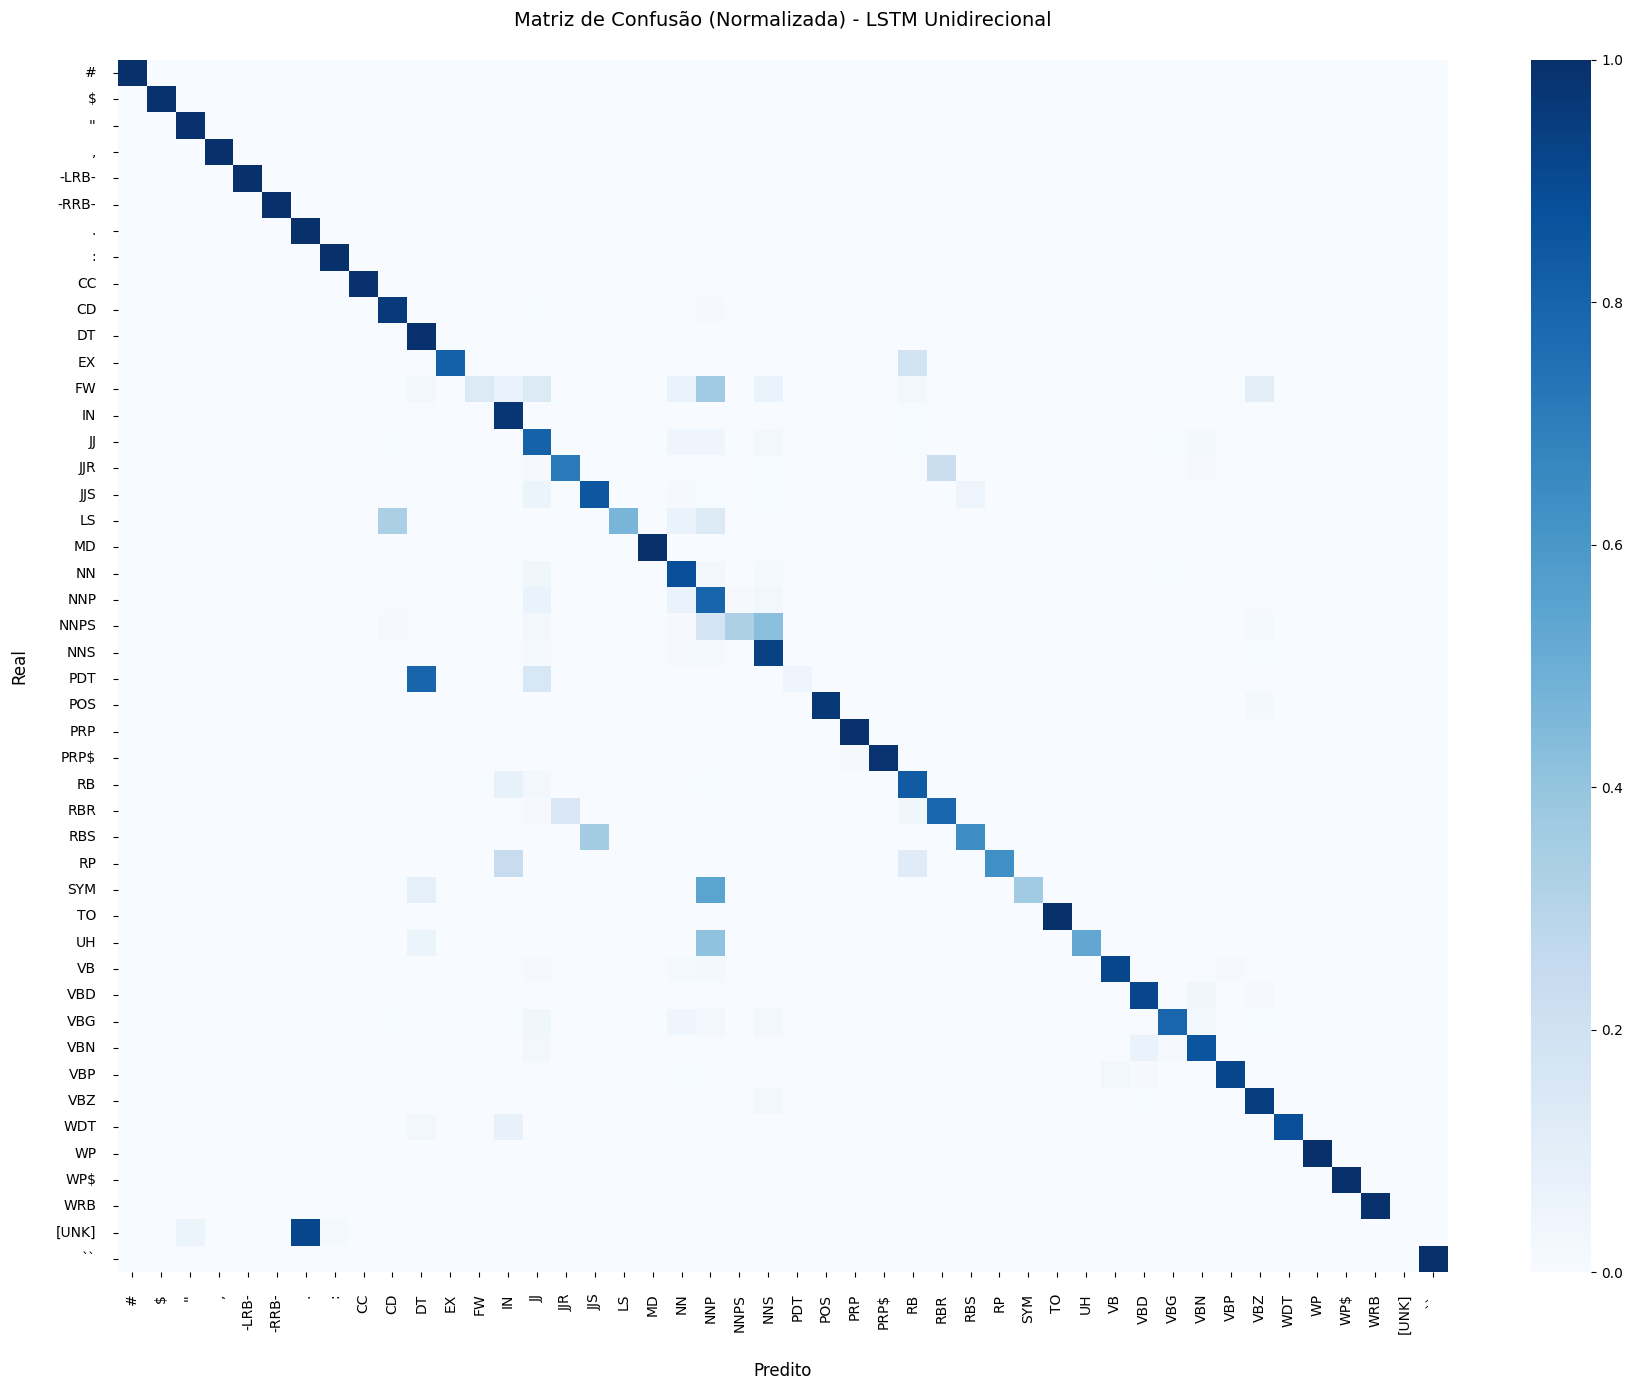

In [ ]:
model_evaluation(lstm_unidirecional_model, X_test, Y_test, tag_lookup, "LSTM Unidirecional")

### Avaliação da RNN Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       0.70      0.99      0.82       733
           ,       1.00      1.00      1.00      6875
       -LRB-       1.00      1.00      1.00       186
       -RRB-       0.93      1.00      0.96       174
           .       0.07      1.00      0.13       378
           :       0.88      1.00      0.94       665
          CC       1.00      1.00      1.00      3250
          CD       0.98      0.97      0.97      4821
          DT       0.99      0.99      0.99     11183
          EX       0.95      1.00      0.98       126
          FW       0.22      0.07      0.10        30
          IN       0.98      0.98      0.98     13487
          JJ       0.85      0.86      0.85      8213
         JJR       0.86      0.82      0.84       423


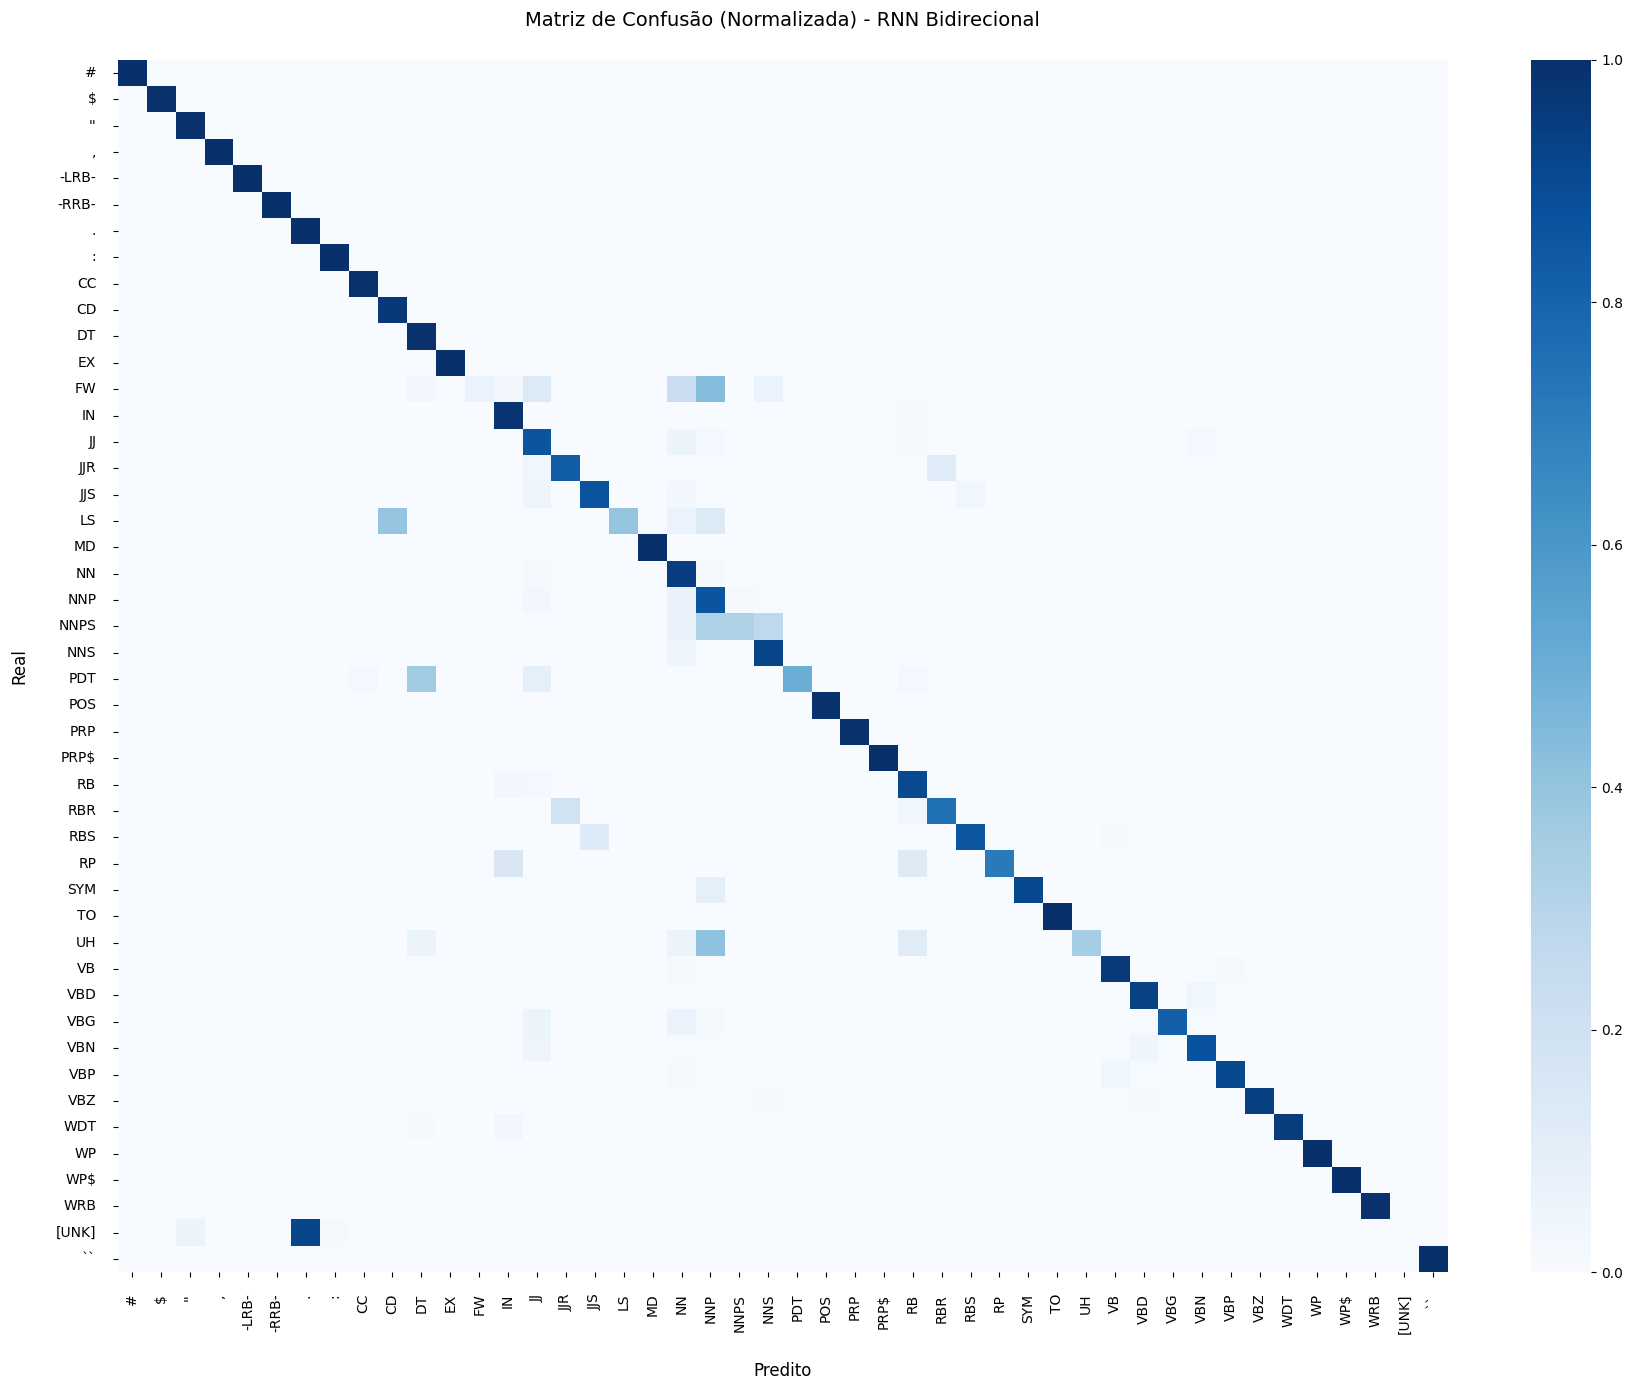

In [ ]:
model_evaluation(rnn_bidirecional_model, X_test, Y_test, tag_lookup, "RNN Bidirecional")

### Avaliação da LSTM Bidirecional

171/171 ━━━━━━━━━━━━━━━━━━━━ 44s 258ms/step

Classification Report Without Padding
              precision    recall  f1-score   support

           #       1.00      1.00      1.00        15
           $       1.00      0.99      1.00       943
          ''       0.70      0.99      0.82       733
           ,       1.00      1.00      1.00      6875
       -LRB-       1.00      1.00      1.00       186
       -RRB-       0.93      1.00      0.96       174
           .       0.07      1.00      0.13       378
           :       0.88      1.00      0.94       665
          CC       1.00      1.00      1.00      3250
          CD       0.98      0.97      0.97      4821
          DT       0.99      0.99      0.99     11183
          EX       0.96      0.98      0.97       126
          FW       0.27      0.10      0.15        30
          IN       0.97      0.99      0.98     13487
          JJ       0.83      0.88      0.86      8213
         JJR       0.85      0.88      0.86       42

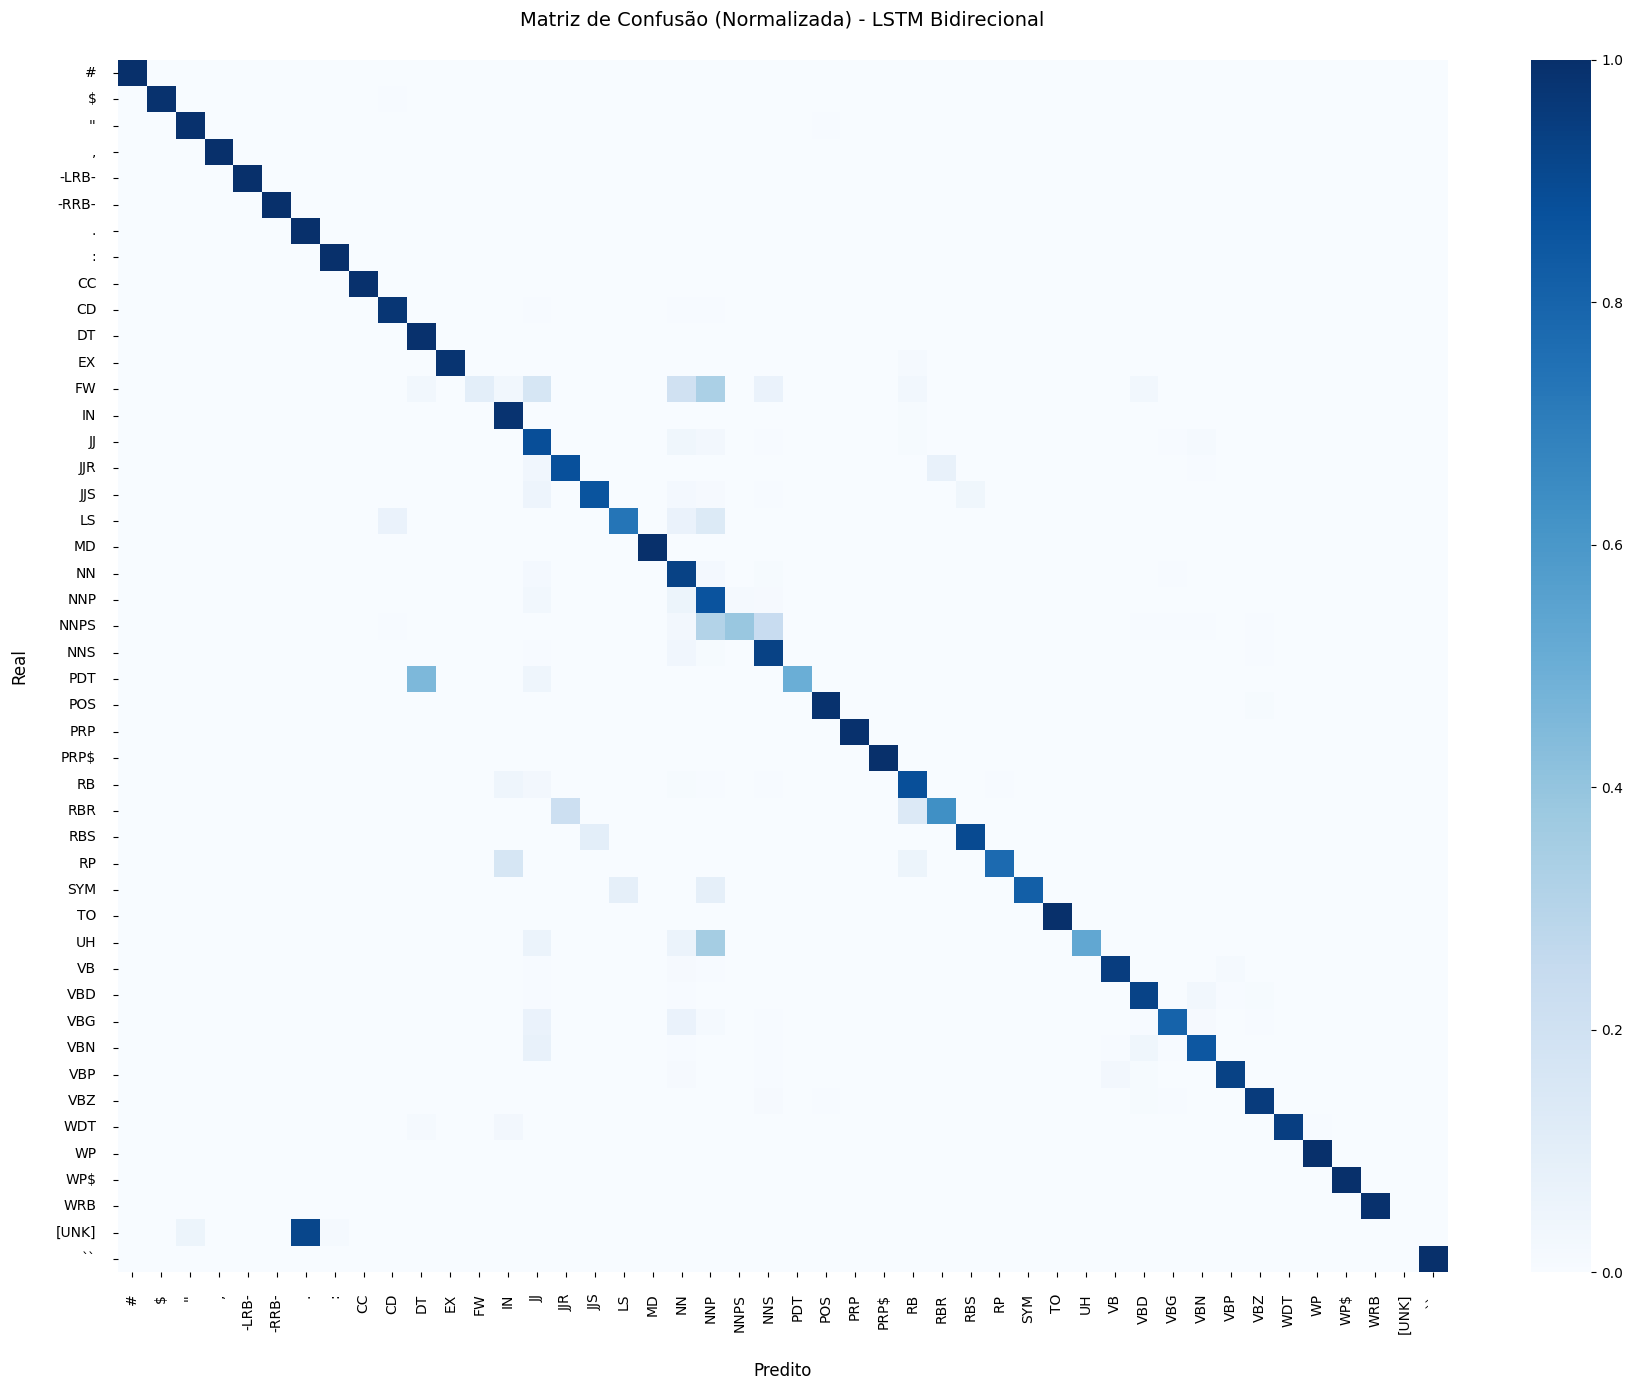

In [ ]:
model_evaluation(lstm_bidirecional_model, X_test, Y_test, tag_lookup, "LSTM Bidirecional")